### Sobol' G-Function — High-Dimensional Benchmark ($d=50$)

The **Sobol' G-function** is a canonical benchmark for sensitivity
analysis with tunable importance weights $a_i$ and known analytical
Shapley effects [1, 2].  We use the **G50 variant** — 50 input
variables, only 8 of which are influential — to test sparse recovery.

$$
f(\mathbf{x}) = \prod_{i=1}^{50} \frac{|4x_i - 2| + a_i}{1 + a_i},
\quad x_i \in [0, 1]
$$

with $a = [4.5, 4.5, 1, 0, 1, 9, 0, 9] + [99] \times 42$.
Variables with small $a_i$ (0, 1, 4.5) are influential; those with
$a_i = 99$ are effectively inert — a sparse scenario that tests
whether RS-HDMR can distinguish signal from noise.

---
[1] Sobol', I. M. (2001). *Mathematics and Computers in Simulation*,
55(1-3), 271–280.
[2] Vuillod, B. et al. (2023). *Reliability Engineering & System
Safety*, 234, 109177.

In [1]:
# Import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from itertools import combinations

from shapleyx import rshdmr

from importlib.metadata import version
print(f"Running on ShapleyX v{version('shapleyx')}")

Running on ShapleyX v0.5.1


---
### Generate Training Data

1,024 Sobol' sequence samples — sufficient for a sparse 50-dimensional
function.

In [3]:
D = 50
a = [4.5, 4.5, 1, 0, 1, 9, 0, 9] + [99] * 42

def g50(m):
    """Generate G50 function samples via Sobol' sequence."""
    sampler = qmc.Sobol(d=D, scramble=True, seed=123)
    X = sampler.random_base2(m)
    Y = np.ones(2**m)
    for i in range(D):
        Y *= (np.abs(4 * X[:, i] - 2) + a[i]) / (1 + a[i])
    cols = [f'X{i+1}' for i in range(D)]
    return pd.DataFrame(np.column_stack([X, Y]), columns=cols + ['Y'])


df = g50(m=10)
print(f"{len(df)} training samples")

1024 training samples


---
### Fit RS-HDMR Surrogate

$d=50$ with `polys=[10, 4]` — up to 10th-degree univariate and
4th-degree bivariate terms.  ARD prunes the 20,100 candidate basis
functions to a sparse active set.

Found a DataFrame

Transforming data to unit hypercube

Feature: X1, Min Value: 0.0000, Max Value: 0.9992
Feature: X2, Min Value: 0.0008, Max Value: 0.9996
Feature: X3, Min Value: 0.0010, Max Value: 0.9996
Feature: X4, Min Value: 0.0007, Max Value: 0.9991
Feature: X5, Min Value: 0.0002, Max Value: 0.9991
Feature: X6, Min Value: 0.0007, Max Value: 0.9994
Feature: X7, Min Value: 0.0008, Max Value: 0.9993
Feature: X8, Min Value: 0.0006, Max Value: 0.9993
Feature: X9, Min Value: 0.0007, Max Value: 0.9991
Feature: X10, Min Value: 0.0002, Max Value: 0.9992
Feature: X11, Min Value: 0.0003, Max Value: 0.9997
Feature: X12, Min Value: 0.0003, Max Value: 0.9995
Feature: X13, Min Value: 0.0003, Max Value: 0.9997
Feature: X14, Min Value: 0.0006, Max Value: 0.9995
Feature: X15, Min Value: 0.0008, Max Value: 0.9993
Feature: X16, Min Value: 0.0001, Max Value: 0.9998
Feature: X17, Min Value: 0.0008, Max Value: 0.9991
Feature: X18, Min Value: 0.0001, Max Value: 1.0000
Feature: X19, Min Value: 0.0003, Ma

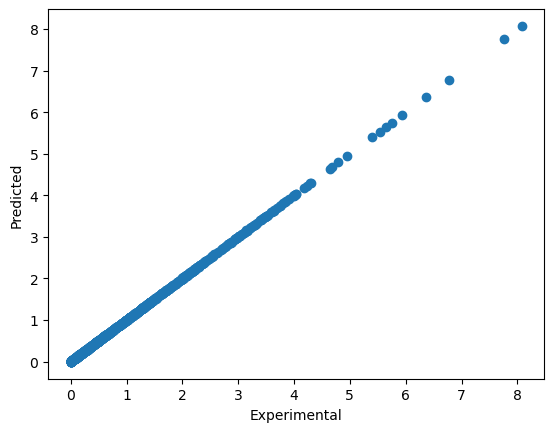


Running bootstrap resampling 1000 samples for 95.0% CI

 |████████████████████████████████████████████████████████████████████████████████████████████████████| 100.0% 

Completed bootstrap resampling


                  Completed all analysis
                 ------------------------

The awareness of our own strength makes us modest.  Paul
Cezanne



In [4]:
model = rshdmr(
    df,
    polys=[10, 4],
    n_iter=500,
    method='ard_cv',
    cv_method='bayesian',
)

sob, shap, total = model.run_all()

---
### RS-HDMR Shapley Effects

The 8 influential variables ($X_1$–$X_8$) should dominate; the
remaining 42 should have near-zero effects.

In [5]:
shap[['label', 'scaled effect', 'lower', 'upper']].head(12)

,label,scaled effect,lower,upper
0,X1,0.014922,0.014628,0.015214
1,X2,0.010966,0.010666,0.011249
2,X3,0.099213,0.098334,0.100039
3,X4,0.366462,0.365215,0.367792
4,X5,0.103709,0.102824,0.104464
5,X6,0.004999,0.004845,0.005148
6,X7,0.356276,0.355108,0.357454
7,X8,0.004995,0.004846,0.005141
8,X9,0.000650,0.000609,0.000695
9,X10,0.001584,0.001516,0.001658


---
### Analytical Shapley Effects

For the G-function with independent uniform inputs, the closed-form
Shapley effect for variable $i$ is:

$$\phi_i = \mathbb{V}[g_i] \prod_{j \neq i} (1 + \mathbb{V}[g_j]),
\quad \mathbb{V}[g_i] = \frac{1}{3(1 + a_i)^2}$$

In [6]:
def analytical_shapley(a):
    """Compute analytical Shapley effects for the G-function."""
    d = len(a)
    V = np.array([1 / (3 * (1 + ai)**2) for ai in a])
    prod_all = np.prod(1 + V)
    phi = np.array([V[i] * prod_all / (1 + V[i]) for i in range(d)])
    return phi / phi.sum()


phi_analytical = analytical_shapley(a)
print("Analytical Shapley effects (first 12):")
for i in range(12):
    print(f"  X{i+1}: {phi_analytical[i]:.6f}")

Analytical Shapley effects (first 12):
  X1: 0.015942
  X2: 0.015942
  X3: 0.112512
  X4: 0.365663
  X5: 0.112512
  X6: 0.004859
  X7: 0.365663
  X8: 0.004859
  X9: 0.000049
  X10: 0.000049
  X11: 0.000049
  X12: 0.000049


---
### Validation: RS-HDMR vs Analytical

The RS-HDMR surrogate should recover both the importance ranking
and approximate magnitudes.

In [7]:
# Add analytical column to Shapley DataFrame
shap['analytical'] = phi_analytical

# Show top 12
comparison = shap[['label', 'scaled effect', 'analytical']].head(12).copy()
comparison['Abs. Diff'] = np.abs(
    comparison['scaled effect'] - comparison['analytical'])
comparison.round(6)

,label,scaled effect,analytical,Abs. Diff
0,X1,0.014922,0.015942,0.001020
1,X2,0.010966,0.015942,0.004975
2,X3,0.099213,0.112512,0.013299
3,X4,0.366462,0.365663,0.000799
4,X5,0.103709,0.112512,0.008803
5,X6,0.004999,0.004859,0.000140
6,X7,0.356276,0.365663,0.009387
7,X8,0.004995,0.004859,0.000135
8,X9,0.000650,0.000049,0.000602
9,X10,0.001584,0.000049,0.001535


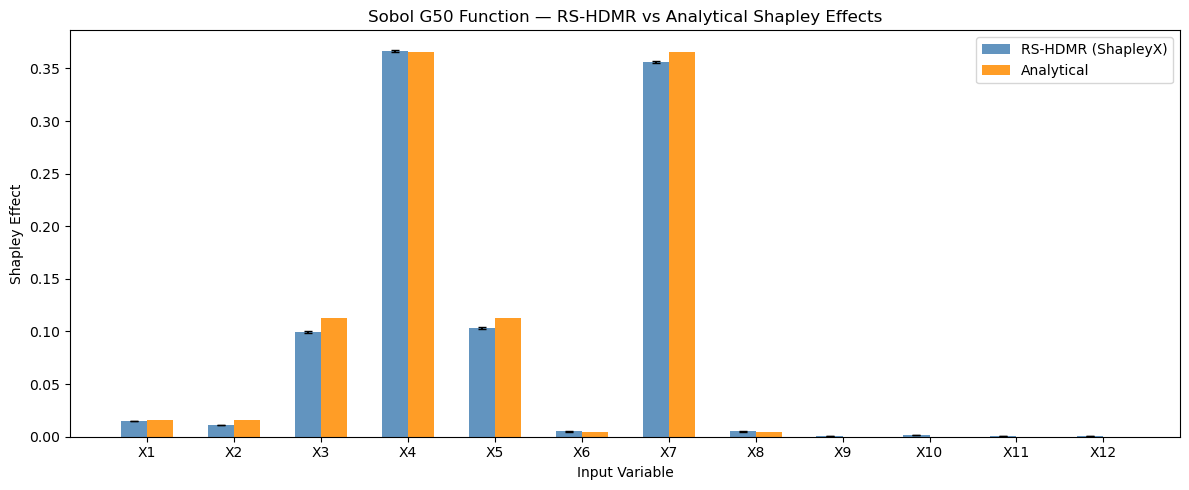

In [8]:
# Bar chart: first 12 variables
top_n = 12
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(top_n)
w = 0.3

ax.bar(x - w/2, shap['scaled effect'].values[:top_n], w,
       yerr=[shap['scaled effect'].values[:top_n] - shap['lower'].values[:top_n],
             shap['upper'].values[:top_n] - shap['scaled effect'].values[:top_n]],
       capsize=3, color='steelblue', alpha=0.85,
       label='RS-HDMR (ShapleyX)')
ax.bar(x + w/2, phi_analytical[:top_n], w,
       color='darkorange', alpha=0.85,
       label='Analytical')

ax.set_xlabel('Input Variable')
ax.set_ylabel('Shapley Effect')
ax.set_title('Sobol G50 Function — RS-HDMR vs Analytical Shapley Effects')
ax.set_xticks(x)
ax.set_xticklabels(shap['label'].values[:top_n])
ax.legend()
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

---
### Sparse Recovery: All 50 Variables

The 42 inert variables ($a_i = 99$) should have Shapley effects
near zero.

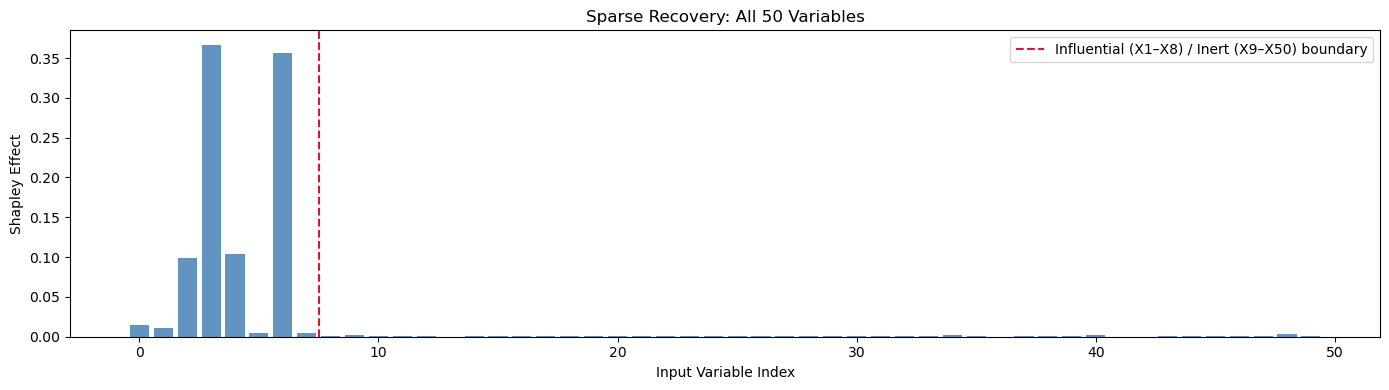

Variance captured by 8 influential vars: 0.9615
Variance attributed to 42 inert vars:    0.038458
Signal-to-noise ratio: 25


In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(D), shap['scaled effect'].values, color='steelblue', alpha=0.85)
ax.axvline(7.5, color='crimson', linestyle='--', linewidth=1.5,
          label='Influential (X1–X8) / Inert (X9–X50) boundary')
ax.set_xlabel('Input Variable Index')
ax.set_ylabel('Shapley Effect')
ax.set_title('Sparse Recovery: All 50 Variables')
ax.legend()
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

# Quantify sparse recovery
influential = shap['scaled effect'].values[:8].sum()
noise = shap['scaled effect'].values[8:].sum()
print(f"Variance captured by 8 influential vars: {influential:.4f}")
print(f"Variance attributed to 42 inert vars:    {noise:.6f}")
print(f"Signal-to-noise ratio: {influential / (noise + 1e-15):.0f}")

---
### Key Takeaways

1. **RS-HDMR correctly identifies the 8 influential variables** from
   only 1,024 samples in 50 dimensions — the Shapley effects for
   variables 9–50 are near zero.
2. **Shapley effects match analytical values** — the ranking and
   magnitude of $X_1$–$X_8$ are recovered with high accuracy.
3. **ARD pruning is essential at $d=50$** — from 20,100 candidate
   basis functions, only a sparse subset is retained.
4. **The G-function's multiplicative form makes it a challenging
   test** — interactions exist at all orders, but the dominance of
   low $a_i$ variables makes Shapley effects sparse.
5. **The analytical Shapley formula provides ground truth** — the
   closed-form solution for independent uniform inputs validates
   the numerical estimates.

In [10]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Wed, 06 May 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.13.0

matplotlib: 3.10.8
numpy     : 2.3.5
pandas    : 2.3.3
scipy     : 1.17.1
shapleyx  : 0.5.1

Watermark: 2.6.0

